# 24B. 네 모델의 paired MP3 평가

23번에서 고정한 네 모델과 clean Validation 임계값을 같은 Test 539곡의 clean·MP3 128·64 kbps에 적용했다. 세 조건은 전체 곡 디코딩과 같은 Segment 경계를 사용한다. 압축 결과로 모델을 다시 선택하지 않았으며, 이 후속 계획은 기존 Test 결과가 공개된 뒤 세웠다.

## 1. 입력·출처 동결 확인

`extract_paired_mp3_features.py`는 세 조건의 266-D 특징과 새 clean Log-Mel을 만들고, 과거 `15`번에서 전체 디코딩으로 생성한 MP3 Log-Mel cache를 실제 압축 파일의 표본과 대조했다. `extract_mert_mp3.py`는 sklearn이 없는 별도 프로세스에서 frozen encoder를 CPU에 올려 세 조건의 13×768 embedding을 추출했다. `score_optimized_mp3_robustness.py`는 저장된 checkpoint와 clean Validation 임계값으로 점수를 계산했다. `run_metadata.json`은 protocol/manifest/report hash, 모델 checkpoint hash와 실행 장비를 보존한다.

In [1]:
# 저장된 실행 메타데이터와 세 조건의 paired score·지표를 읽어 입력 출처를 확인한다.
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

RUN = Path("results/model_robustness/mp3/mp3_optimized_20260919T175101Z")
meta = json.loads((RUN / "run_metadata.json").read_text(encoding="utf-8"))
input_qc = json.loads(
    (RUN / "clean_input_reference_qc.json").read_text(encoding="utf-8")
)
metrics = pd.read_csv(RUN / "metrics.csv")
deltas = pd.read_csv(RUN / "paired_deltas.csv")
reference = pd.read_csv(RUN / "clean_vs_final23.csv")
print("Run:", meta["robustness_run_id"], "| source final:", meta["source_final_run_id"])
print("Protocol SHA-256:", meta["protocol_sha256"])
print("Test:", meta["test_segments"], "segments /", meta["test_tracks"], "tracks")
print("Conditions:", meta["conditions"], "| rows:", len(metrics))
display(pd.DataFrame(meta["mert_extraction"]).T)

Run: mp3_optimized_20260919T175101Z | source final: final_binary_20260919T164939Z
Protocol SHA-256: 95f1546ce8e3fcedb66e5ef52488c9255e414965514b5163e1a62b9052e4941e
Test: 1572 segments / 539 tracks
Conditions: ['clean', 'mp3_128', 'mp3_64'] | rows: 24


,model_load_seconds,embedding_extraction_seconds,device,cache_path,cache_sha256,cache_metadata_path,cache_metadata_sha256,cache_provenance
clean,0.745986,1073.94092,cpu,/Users/seungjae/Desktop/SNU/기계학습 & 딥러...,239240dfd841ddb6cc2ae58a02c2409866b53e43bbc5e5...,/Users/seungjae/Desktop/SNU/기계학습 & 딥러...,eb77423f7170ddbcc3dbe7b9e5b7ddd43dcf2b1efcc34f...,"{'condition': 'clean', 'manifest_sha256': '902..."
mp3_128,0.536843,1077.479413,cpu,/Users/seungjae/Desktop/SNU/기계학습 & 딥러...,62058d95beea4ada18121e4921e15fcce928d17256d4ff...,/Users/seungjae/Desktop/SNU/기계학습 & 딥러...,a1f5557050655e96ee0a23460edf278a601b23b517ceb7...,"{'condition': 'mp3_128', 'manifest_sha256': '9..."
mp3_64,0.536843,1025.728478,cpu,/Users/seungjae/Desktop/SNU/기계학습 & 딥러...,3fdcb5c16c96437a65fe4cd5165c7e541ca7b912633542...,/Users/seungjae/Desktop/SNU/기계학습 & 딥러...,3c0d3b260b9a94cac88ade54ee93892144c0c1e11bfacd...,"{'condition': 'mp3_64', 'manifest_sha256': '90..."


세 조건 모두 Test **1572 Segment·539 Track**을 포함했고, 24개 모델×조건×수준 지표가 저장됐다. Clean/MP3는 같은 manifest SHA-256 `9023dcb21bef…`와 사전 고정 protocol SHA-256 `95f1546ce8e3…`을 사용했다. MERT는 CPU에서 Segment 하나씩 추출했고 CNN Test 추론 장비는 `mps`였다.

모델의 학습 상태와 Validation 임계값을 고정한 채 입력의 압축 조건만 바꾸었다. 각 조건의 Track 점수는 같은 Track에 속한 Segment 점수의 평균이다.

기존 원본 Test 수치가 공개된 이력이 있으며, 세 조건의 decoder·특징 추출과 추론 시간은 장비 부하에 영향을 받는다. 모델 간 원점수 크기는 직접 비교하지 않는다.

## 2. 고정 임계값에서의 세 조건 비교

ROC-AUC와 EER는 점수의 분리력을, HTER·Balanced Accuracy·Macro-F1·REAL FPR·FAKE Miss Rate는 **원래 clean Validation 임계값**으로 얻은 분류를 나타낸다. FAKE AP와 REAL AP를 함께 보며, class 비율은 조건마다 같다. Test EER의 교점은 예측 임계값으로 쓰지 않는다.

,model,condition,n_real,n_fake,threshold,roc_auc,ap_fake,ap_real,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter
1,LogisticRegression,clean,45,494,0.563456,0.942915,0.993781,0.724806,0.133333,0.883738,0.764133,0.133333,0.099190,0.116262
3,RBF-SVM,clean,45,494,0.661505,0.958165,0.995543,0.836938,0.115385,0.898943,0.843058,0.155556,0.046559,0.101057
5,Log-Mel CNN,clean,45,494,0.241069,0.984705,0.998557,0.902102,0.074899,0.887854,0.876437,0.200000,0.024291,0.112146
7,Frozen MERT + LR,clean,45,494,0.588751,0.984525,0.998336,0.938087,0.066667,0.936325,0.878657,0.088889,0.038462,0.063675
9,LogisticRegression,mp3_128,45,494,0.563456,0.923707,0.991354,0.682163,0.155556,0.848381,0.741015,0.200000,0.103239,0.151619
11,RBF-SVM,mp3_128,45,494,0.661505,0.946424,0.993913,0.809823,0.133333,0.887832,0.836451,0.177778,0.046559,0.112168
13,Log-Mel CNN,mp3_128,45,494,0.241069,0.914575,0.990292,0.699133,0.177778,0.803014,0.833141,0.377778,0.016194,0.196986
15,Frozen MERT + LR,mp3_128,45,494,0.588751,0.985110,0.998422,0.935255,0.066667,0.944422,0.915035,0.088889,0.022267,0.055578
17,LogisticRegression,mp3_64,45,494,0.563456,0.900090,0.988250,0.635278,0.177778,0.800765,0.614621,0.155556,0.242915,0.199235
19,RBF-SVM,mp3_64,45,494,0.661505,0.907197,0.988918,0.717167,0.155556,0.858457,0.722720,0.155556,0.127530,0.141543


,model,condition,delta_roc_auc,delta_ap_real,delta_eer,delta_balanced_accuracy,delta_macro_f1,delta_real_fpr,delta_fake_miss_rate,delta_hter
2,LogisticRegression,mp3_128,-0.019208,-0.042643,0.022222,-0.035358,-0.023118,0.066667,0.004049,0.035358
3,LogisticRegression,mp3_64,-0.042825,-0.089528,0.044444,-0.082973,-0.149512,0.022222,0.143725,0.082973
6,RBF-SVM,mp3_128,-0.011741,-0.027115,0.017949,-0.011111,-0.006608,0.022222,0.000000,0.011111
7,RBF-SVM,mp3_64,-0.050967,-0.119771,0.040171,-0.040486,-0.120338,0.000000,0.080972,0.040486
10,Log-Mel CNN,mp3_128,-0.070130,-0.202969,0.102879,-0.084840,-0.043295,0.177778,-0.008097,0.084840
11,Log-Mel CNN,mp3_64,-0.300765,-0.626002,0.334008,-0.338372,-0.309656,0.688889,-0.012146,0.338372
14,Frozen MERT + LR,mp3_128,0.000585,-0.002832,0.000000,0.008097,0.036378,0.000000,-0.016194,-0.008097
15,Frozen MERT + LR,mp3_64,-0.024022,-0.092918,0.044444,-0.087854,-0.007765,0.200000,-0.024291,0.087854


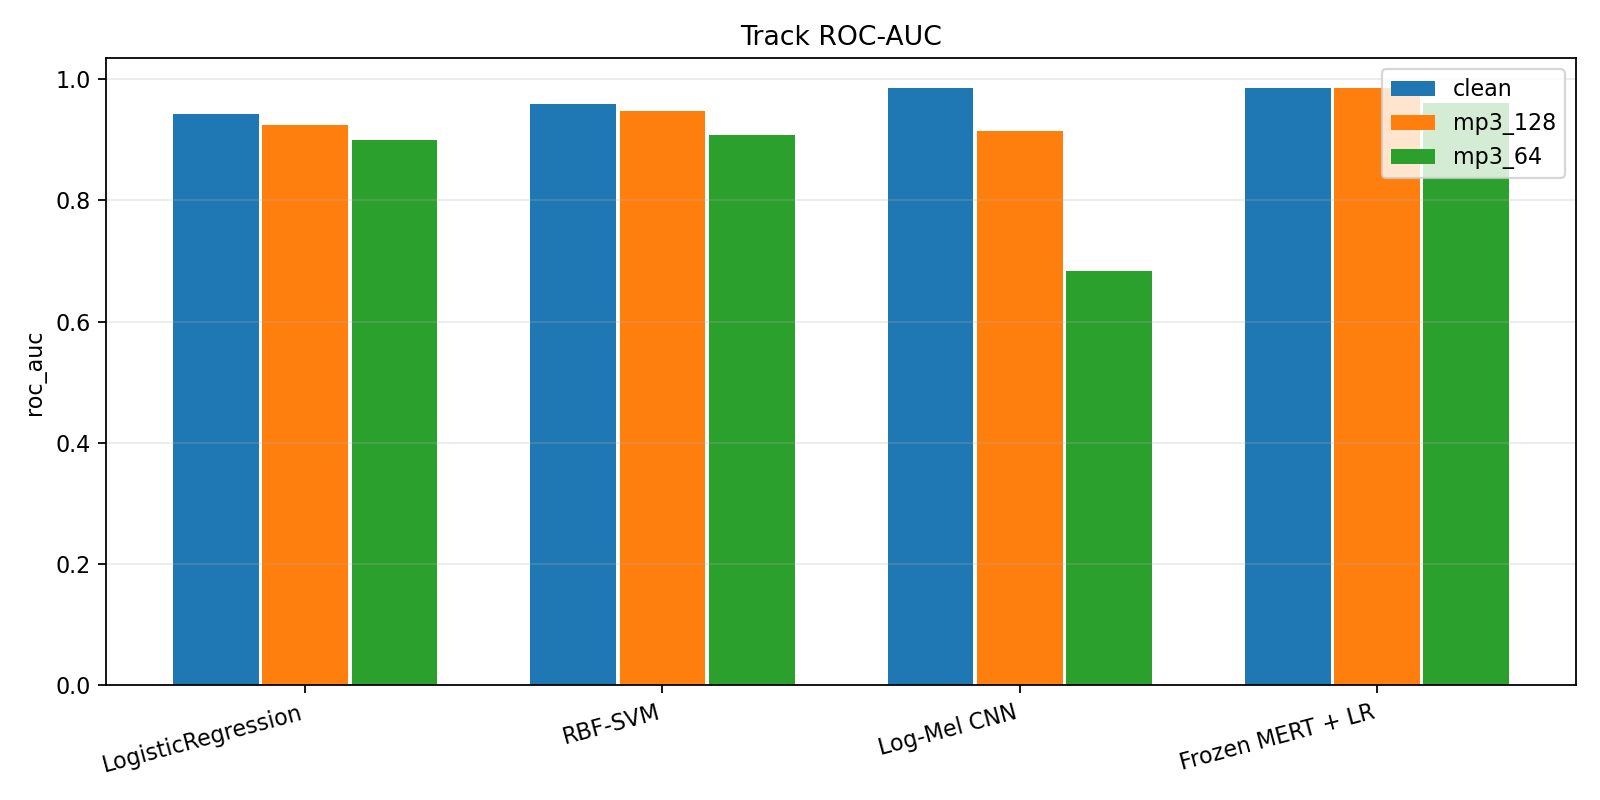

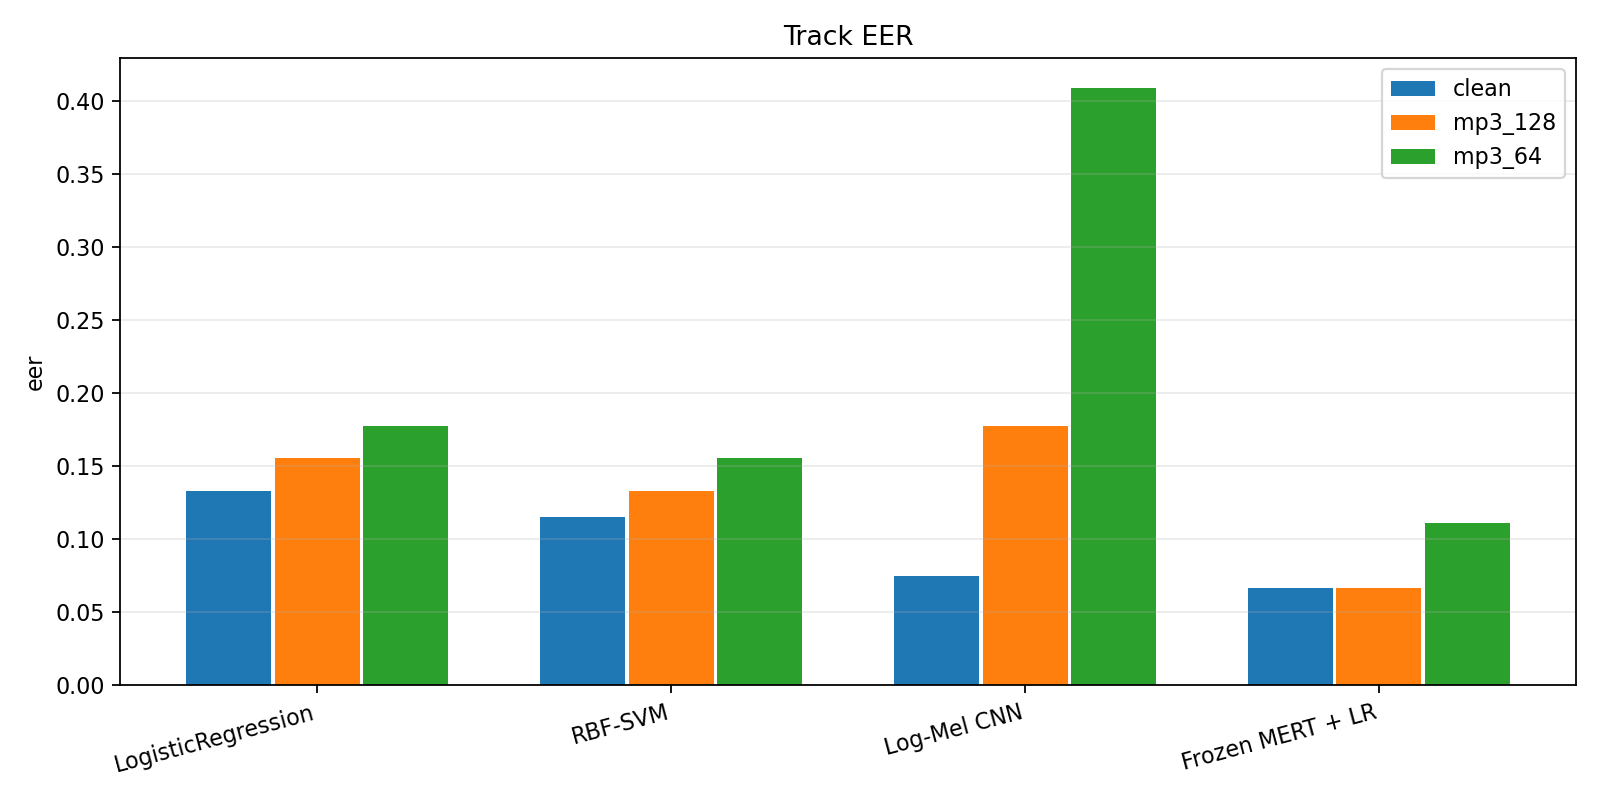

In [2]:
# 같은 Track ID의 clean·128·64 kbps 지표와 clean 대비 변화량을 나란히 표시한다.
track = metrics.loc[metrics.level.eq("track")]
display(
    track[
        [
            "model",
            "condition",
            "n_real",
            "n_fake",
            "threshold",
            "roc_auc",
            "ap_fake",
            "ap_real",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
            "hter",
        ]
    ]
)
display(
    deltas.loc[
        deltas.level.eq("track"),
        [
            "model",
            "condition",
            "delta_roc_auc",
            "delta_ap_real",
            "delta_eer",
            "delta_balanced_accuracy",
            "delta_macro_f1",
            "delta_real_fpr",
            "delta_fake_miss_rate",
            "delta_hter",
        ],
    ]
)
display(Image(filename=str(RUN / "paired_track_roc_auc.png")))
display(Image(filename=str(RUN / "paired_track_eer.png")))

Track Test는 매 조건 **REAL 45·FAKE 494**로 같았다. 아래 괄호는 새 paired clean 대비 변화량이다.

| 모델 | Clean AUC | 128 kbps AUC (Δ) | 64 kbps AUC (Δ) | Clean EER | 128 EER | 64 EER | Clean HTER | 128 HTER | 64 HTER |
|:--|--:|--:|--:|--:|--:|--:|--:|--:|--:|
| LogisticRegression | 0.9429 | 0.9237 (-0.0192) | 0.9001 (-0.0428) | 0.1333 | 0.1556 | 0.1778 | 0.1163 | 0.1516 | 0.1992 |
| RBF-SVM | 0.9582 | 0.9464 (-0.0117) | 0.9072 (-0.0510) | 0.1154 | 0.1333 | 0.1556 | 0.1011 | 0.1122 | 0.1415 |
| Log-Mel CNN | 0.9847 | 0.9146 (-0.0701) | 0.6839 (-0.3008) | 0.0749 | 0.1778 | 0.4089 | 0.1121 | 0.1970 | 0.4505 |
| Frozen MERT + LR | 0.9845 | 0.9851 (+0.0006) | 0.9605 (-0.0240) | 0.0667 | 0.0667 | 0.1111 | 0.0637 | 0.0556 | 0.1515 |

64 kbps에서 clean 대비 AUC 하락폭이 가장 큰 모델은 **Log-Mel CNN**였다. 압축 후 오류 방향은 모델마다 다르며, 64 kbps REAL FPR 증가폭이 가장 큰 모델은 **Log-Mel CNN**였다. AUC·EER와 고정 임계값의 HTER를 함께 읽어 분리력 변화와 분류 오류 변화를 구분한다.

REAL은 45 Track뿐이어서 한 건의 REAL 오탐 변화가 FPR 약 2.22%p에 해당한다. FAKE 비율이 91.65%이므로 높은 FAKE AP만으로 REAL 탐지 성능을 설명할 수 없다. 모델의 sigmoid·확률·margin 점수는 서로 같은 척도가 아니다.

## 3. Segment 변화와 원래 23번 clean 기준 대조

새 paired clean은 MP3와 동일한 전체 디코딩 경로에서 다시 추출했다. 23번의 clean score는 원래 추출 경로에서 만든 값이므로, 섞어서 clean→MP3 변화량을 계산하지 않는다. 입력과 score·지표 차이를 기록해 추출 방식의 영향을 드러낸다.

In [3]:
# Segment 지표와 새 paired clean·기존 23번 clean의 차이를 별도로 확인한다.
display(
    metrics.loc[
        metrics.level.eq("segment"),
        [
            "model",
            "condition",
            "n_real",
            "n_fake",
            "roc_auc",
            "ap_fake",
            "ap_real",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
            "hter",
        ],
    ]
)
display(
    reference[
        [
            "model",
            "level",
            "segment_score_mean_abs_diff",
            "segment_score_max_abs_diff",
            "delta_roc_auc",
            "delta_eer",
            "delta_balanced_accuracy",
            "delta_hter",
        ]
    ]
)
print(
    "Clean input comparison with final 23:",
    json.dumps(input_qc, ensure_ascii=False, indent=2),
)

,model,condition,n_real,n_fake,roc_auc,ap_fake,ap_real,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter
0,LogisticRegression,clean,135,1437,0.895317,0.988084,0.523724,0.192593,0.809882,0.661014,0.200000,0.180237,0.190118
2,RBF-SVM,clean,135,1437,0.914142,0.989834,0.671113,0.162963,0.846741,0.719022,0.177778,0.128740,0.153259
4,Log-Mel CNN,clean,135,1437,0.959963,0.995662,0.804383,0.118519,0.882680,0.799560,0.162963,0.071677,0.117320
6,Frozen MERT + LR,clean,135,1437,0.973097,0.997160,0.870308,0.080028,0.922029,0.817560,0.081481,0.074461,0.077971
8,LogisticRegression,mp3_128,135,1437,0.879610,0.986205,0.455556,0.205985,0.785696,0.651865,0.251852,0.176757,0.214304
10,RBF-SVM,mp3_128,135,1437,0.900106,0.987819,0.637048,0.177778,0.837841,0.725131,0.207407,0.116910,0.162159
12,Log-Mel CNN,mp3_128,135,1437,0.885399,0.986381,0.545323,0.180237,0.730155,0.724856,0.488889,0.050800,0.269845
14,Frozen MERT + LR,mp3_128,135,1437,0.973716,0.997290,0.859009,0.081420,0.917305,0.843818,0.111111,0.054280,0.082695
16,LogisticRegression,mp3_64,135,1437,0.850259,0.983293,0.355942,0.237996,0.776332,0.589410,0.170370,0.276966,0.223668
18,RBF-SVM,mp3_64,135,1437,0.856857,0.982239,0.525140,0.214815,0.786940,0.635144,0.222222,0.203897,0.213060


,model,level,segment_score_mean_abs_diff,segment_score_max_abs_diff,delta_roc_auc,delta_eer,delta_balanced_accuracy,delta_hter
0,LogisticRegression,segment,0.008191,0.078499,0.001866,-1.561896e-03,4.971778e-03,-4.971778e-03
1,LogisticRegression,track,0.008191,0.078499,0.001035,2.775558e-17,-3.036437e-03,3.036437e-03
2,RBF-SVM,segment,0.032757,0.198898,0.000778,8.326673e-17,9.023428e-03,-9.023428e-03
3,RBF-SVM,track,0.032757,0.198898,-0.000450,-1.012146e-02,-1.012146e-03,1.012146e-03
4,Log-Mel CNN,segment,0.000172,0.003856,0.000036,2.775558e-17,0.000000e+00,0.000000e+00
5,Log-Mel CNN,track,0.000172,0.003856,0.000180,0.000000e+00,0.000000e+00,5.551115e-17
6,Frozen MERT + LR,segment,0.001103,0.084890,-0.000015,1.391788e-03,3.479471e-04,-3.479471e-04
7,Frozen MERT + LR,track,0.001103,0.084890,0.000045,6.938894e-17,-1.110223e-16,6.938894e-17


Clean input comparison with final 23: {
  "comparison": "23 offset-loaded clean inputs vs new full-decode paired clean inputs",
  "handcrafted": {
    "max_abs_diff": 107.93295710921393,
    "mean_abs_diff": 0.015424948931968836,
    "segments_with_any_diff_gt_1e_6": 1572
  },
  "logmel": {
    "max_abs_diff": 0.521728515625,
    "mean_abs_diff": 5.249706473313321e-05,
    "segments_with_any_exact_diff": 1572
  },
  "mert_selected_layer": {
    "layer": 4,
    "max_abs_diff": 0.04296875,
    "mean_abs_diff": 0.00047443609219044447,
    "segments_with_any_exact_diff": 1572
  }
}


새 paired clean과 23번 clean의 입력 차이는 handcrafted 평균 절댓값 **0.0154249**, Log-Mel 평균 절댓값 **5.24971e-05**, MERT 선택 layer 평균 절댓값 **0.000474436**였다. 두 clean 추출의 Track AUC 차이의 최대 절댓값은 네 모델 중 **0.001035**였다. 각 모델·수준의 정확한 차이와 Segment 조건별 전 지표는 위 표 및 CSV에 있다.

23번의 clean과 새 paired clean을 동일한 전처리 결과로 취급할 수 있는지 직접 확인했다. 강건성 Delta는 일관된 전체 디코딩 경로의 새 paired clean에서 계산했다.

입력 차이는 압축 자체 외에 전체 디코딩과 이전 segment 단위 로딩 방식의 차이를 포함할 수 있다. 이 비교는 Test 기반 재튜닝이 아니며, 저장된 clean Validation 임계값은 그대로 유지했다.

## 4. 결론과 한계

네 Optimized 모델의 clean/128/64 kbps Segment·Track 지표, 동일 ID의 raw score와 변화량은 `results/model_robustness/mp3/` 아래 이 실행 ID 디렉터리에 저장했다. 계산량은 `inference_times.csv`, MERT 추출 시간은 `run_metadata.json`에 있다.

이 표는 고정 모델이 압축 입력에 얼마나 민감한지 비교한다. 분리력과 REAL 오탐·FAKE 누락을 함께 보고, 한 지표만으로 모델의 전체 강건성을 단정하지 않는다.

이 실험은 이미 공개된 Test 결과를 본 뒤 설계한 후속 분석이다. 128/64 kbps와 한 가지 transcode 경로만 다루며 다른 codec·플랫폼 처리를 대표하지 않는다. FMA REAL과 Echoes TTA FAKE의 출처·장르·제작 방식 차이, REAL Track 45개의 작은 표본, MERT의 외부 사전학습 데이터 중복 불확실성을 남긴다. Unseen-generator 일반화는 [별도 고정 설정 재학습 실험](../docs/UNSEEN_FIXED_PROTOCOL.md)으로 평가한다.